<a href="https://colab.research.google.com/github/promeroec/mesa-abm/blob/main/notebooks/mbanks_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf mesa-abm
!git clone https://github.com/promeroec/mesa-abm.git
%cd mesa-abm
!pip install -r requirements.txt



Cloning into 'mesa-abm'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 118 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 178.22 KiB | 5.94 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/mesa-abm


In [20]:
from mbanksdd.dd_banks_v6 import (
    make_isolated_model,
    make_interbank_model,
    make_big_bank_model,
)

p_impatient = 0.5
steps = 40
cust_per_step = 1

iso_model = make_isolated_model(
    num_banks=4,
    customers_per_bank=10,
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    #seed=123,
)
iso_model.run_model(steps)

inter_model = make_interbank_model(
    num_banks=4,
    customers_per_bank=10,
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    #seed=123,
)
inter_model.run_model(steps)

big_model = make_big_bank_model(
    big_bank_index=0,
    big_size=10,
    small_size=5,
    num_small_banks=3,
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    #seed=123,
)
big_model.run_model(steps)

print("Isolated – failed banks:",  [b.unique_id for b in iso_model.banks if b.failed])
print("Interbank – failed banks:", [b.unique_id for b in inter_model.banks if b.failed])
print("Big-bank – failed banks:",  [b.unique_id for b in big_model.banks if b.failed])


Isolated – failed banks: ['B0', 'B1', 'B2', 'B3']
Interbank – failed banks: ['B1', 'B3']
Big-bank – failed banks: ['B0']


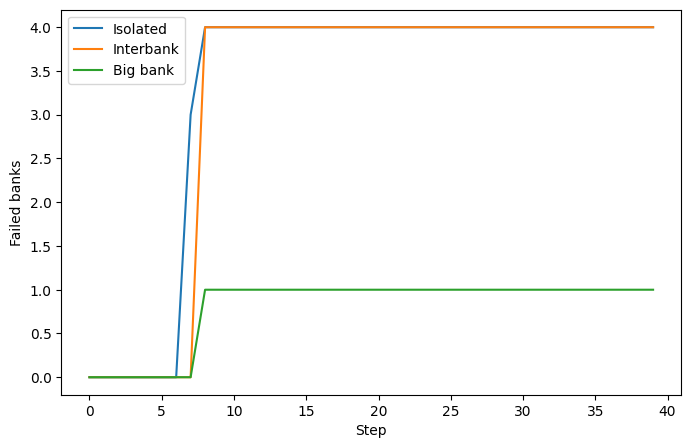

In [10]:
import matplotlib.pyplot as plt

iso_df   = iso_model.datacollector.get_model_vars_dataframe()
inter_df = inter_model.datacollector.get_model_vars_dataframe()
big_df   = big_model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(8, 5))
plt.plot(iso_df["num_failed_banks"],   label="Isolated")
plt.plot(inter_df["num_failed_banks"], label="Interbank")
plt.plot(big_df["num_failed_banks"],   label="Big bank")
plt.xlabel("Step")
plt.ylabel("Failed banks")
plt.legend()
plt.show()


In [11]:
def freq_runs(make_model_fn, label, p_impatient=0.5,
              n_runs=50, n_steps=40, cust_per_step=1):
    count_any = 0
    for _ in range(n_runs):
        m = make_model_fn(
            impatient_probability=p_impatient,
            customers_per_step=cust_per_step,
            seed=None,
        )
        m.run_model(n_steps)
        if any(b.failed for b in m.banks):
            count_any += 1
    print(f"{label}: {count_any}/{n_runs} runs with at least one bank failure")

freq_runs(make_isolated_model,  "Isolated",  p_impatient=0.5)
freq_runs(make_interbank_model, "Interbank", p_impatient=0.5)
freq_runs(make_big_bank_model,  "Big bank",  p_impatient=0.5)


Isolated: 50/50 runs with at least one bank failure
Interbank: 50/50 runs with at least one bank failure
Big bank: 50/50 runs with at least one bank failure
